In [27]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torch.optim import lr_scheduler
import numpy as np
import time
import matplotlib
from matplotlib import pyplot as pp
import scipy
from scipy.integrate import solve_ivp
import random
import functools
import pickle

import pandas as pd
import functools
from scipy.optimize import curve_fit
from scipy import signal, optimize
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.linalg import lstsq

from scipy.linalg import inv
from scipy.optimize import fsolve
from scipy.optimize import least_squares
from scipy.stats import trim_mean
from scipy.fft import fft, fftfreq
from scipy.integrate import solve_ivp
import control as ct
from scipy.signal import csd, welch



data

In [12]:
def wrap_angle(x):
    """Wrap angle(s) in radians to (-pi, pi]."""
    return (x + np.pi) % (2 * np.pi) - np.pi

# Load the data and unpack columns into variables
t, V, alpha, gamma, Q, delta_T, delta_e = np.loadtxt(
    'flight_data.txt', 
    unpack=True
)

alpha   = np.radians(alpha)
gamma   = np.radians(gamma)
Q       = np.radians(Q)
delta_e = np.radians(delta_e)

#real parameters of aircraft
g=9.8; rho=1.225; S=0.25; cbar=0.2; m=1.2; Jy=0.05

# ── Load data (replace with your arrays) ──────────────────────────────
# t, V, alpha, gamma, Q, delta_T, delta_e

N  = len(t)
dt = t[1] - t[0]

def deriv(x): return np.gradient(x, dt)
def W(x):     return x * np.hanning(N)   # windowed FFT
def F(x):     return fft(W(x))

freqs = fftfreq(N, dt)

Vdot     = deriv(V)
alphadot = deriv(alpha)
gammadot = deriv(gamma)
Qdot     = deriv(Q)
qhat     = cbar * Q / (2 * V)
q_dyn    = 0.5 * rho * V**2




get trim point for linearization

In [13]:
x0 = np.array([
    np.median(V),
    np.median(alpha),
    np.median(wrap_angle(gamma)),
    np.median(Q)
])
u0 = np.array([
    np.median(delta_T),
    np.median(delta_e)
])

print(f"Operating point:")
print(f"  V     = {x0[0]:.4f} m/s")
print(f"  alpha = {np.degrees(x0[1]):.4f} deg")
print(f"  gamma = {np.degrees(x0[2]):.4f} deg")
print(f"  Q     = {np.degrees(x0[3]):.4f} deg/s")
print(f"  dT    = {u0[0]:.4f} N")
print(f"  de    = {np.degrees(u0[1]):.4f} deg")

Operating point:
  V     = 31.0772 m/s
  alpha = 0.0112 deg
  gamma = 6.4787 deg
  Q     = 0.3937 deg/s
  dT    = 6.2515 N
  de    = 0.0083 deg


fitting

In [14]:
def dynamics(x, u, params):
    V, alpha, gamma, Q       = x
    delta_T, delta_e         = u
    CL0, CL_alpha, CD0, k_CD, CM0, CM_alpha, CM_Q, CM_e = params

    V_safe = max(V, 1e-3)
    qhat   = cbar * Q / (2 * V_safe)

    CL = CL0 + CL_alpha * alpha
    CD = CD0 + k_CD * CL**2
    CM = CM0 + CM_alpha * alpha + CM_Q * qhat + CM_e * delta_e

    q_dyn = 0.5 * rho * V**2
    L     = q_dyn * S * CL
    D     = q_dyn * S * CD
    M     = q_dyn * S * cbar * CM
    T     = delta_T

    Vdot     = (-D + T*np.cos(alpha) - m*g*np.sin(gamma)) / m
    gammadot = ( L + T*np.sin(alpha) - m*g*np.cos(gamma)) / (m * V_safe)
    Qdot     = M / Jy
    alphadot = Q - gammadot

    return np.array([Vdot, alphadot, gammadot, Qdot])

def linearise(x0, u0, params, eps=1e-6):
    """
    Computes the A and B matrices for the system dot{x} = Ax + Bu
    around the equilibrium point (x0, u0) using central differences.
    """
    nx = len(x0)
    nu = len(u0)
    
    A = np.zeros((nx, nx))
    B = np.zeros((nx, nu))
    
    # --- Compute A matrix (df/dx) ---
    # We nudge each state variable one by one
    for i in range(nx):
        x_plus = x0.copy()
        x_minus = x0.copy()
        
        x_plus[i] += eps
        x_minus[i] -= eps
        
        # Central difference formula: (f(x+eps) - f(x-eps)) / (2*eps)
        f_plus = dynamics(x_plus, u0, params)
        f_minus = dynamics(x_minus, u0, params)
        
        A[:, i] = (f_plus - f_minus) / (2 * eps)
        
    # --- Compute B matrix (df/du) ---
    # We nudge each input variable one by one
    for j in range(nu):
        u_plus = u0.copy()
        u_minus = u0.copy()
        
        u_plus[j] += eps
        u_minus[j] -= eps

        f_plus = dynamics(x0, u_plus, params)
        f_minus = dynamics(x0, u_minus, params)
        
        B[:, j] = (f_plus - f_minus) / (2 * eps)
        
    return A, B


def get_aircraft_tfs(x0, u0, params):
    A, B = linearise(x0, u0, params)
    nx, nu = B.shape
    
    # Pre-define names for clarity
    state_names = ['V', 'alpha', 'gamma', 'Q']
    input_names = ['delta_T', 'delta_e']
    
    tf_matrix = {} # Using a dict for easier access: tfs['delta_e']['Q']
    
    for j in range(nu):
        u_name = input_names[j]
        tf_matrix[u_name] = {}
        
        for i in range(nx):
            x_name = state_names[i]
            
            # SISO selection
            C_single = np.zeros((1, nx))
            C_single[0, i] = 1
            B_single = B[:, [j]]
            
            # Create system - Note: D is usually 0 in aircraft dynamics
            sys_siso = ct.ss(A, B_single, C_single, 0)
            
            # Clean up the TF: removes tiny numerical noise (e.g., 1e-18)
            tf = ct.tf(sys_siso)
            tf_matrix[u_name][x_name] = tf
            
    return tf_matrix, A, B
        


Show Tfs

Transfer Function: delta_T -> V

  0.8333 s^3 + 27.67 s^2 + 474.6 s - 8.785
---------------------------------------------
s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_T -> alpha

-5.228e-06 s^3 - 0.02984 s^2 + 0.1708 s - 0.02224
-------------------------------------------------
  s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_T -> gamma

5.228e-06 s^3 + 0.02984 s^2 + 0.4548 s + 20.04
----------------------------------------------
s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_T -> Q

4.263e-14 s^3 + 0.6256 s^2 + 20.02 s + 6.253e-13
------------------------------------------------
 s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_e -> V

  -6.821e-13 s^2 + 1.054e+04 s + 1.034e+05
---------------------------------------------
s^

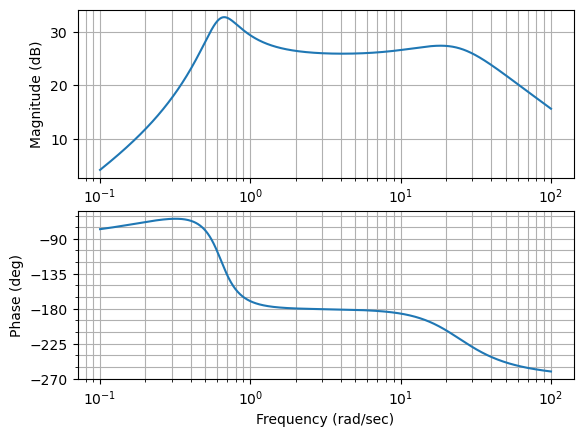

In [15]:
# --- Usage ---
# params = [CL0, CL_alpha, CD0, k_CD, CM0, CM_alpha, CM_Q, CM_e]
theta_true = np.array([0.2, 4.5, 0.04, 0.08, 0.02, -0.5, -8.0, -1.0])
tfs = get_aircraft_tfs(x0, u0, theta_true)

state_names = ['V', 'alpha', 'gamma', 'Q']
input_names = ['delta_T', 'delta_e']

# Unpack the three return values
tfs_dict, A_mat, B_mat = get_aircraft_tfs(x0, u0, theta_true)

state_names = ['V', 'alpha', 'gamma', 'Q']
input_names = ['delta_T', 'delta_e']

for u_name in input_names:
    for x_name in state_names:
        print(f"Transfer Function: {u_name} -> {x_name}")
        # Access using the names (keys) instead of [i][j]
        print(tfs_dict[u_name][x_name]) 
        print("-" * 40)

sys = tfs_dict['delta_e']['Q']

mag, phase, omega = ct.bode_plot(sys, dB=True)
plt.show()

Get FRFs

Using nperseg=256, noverlap=128 for N=480


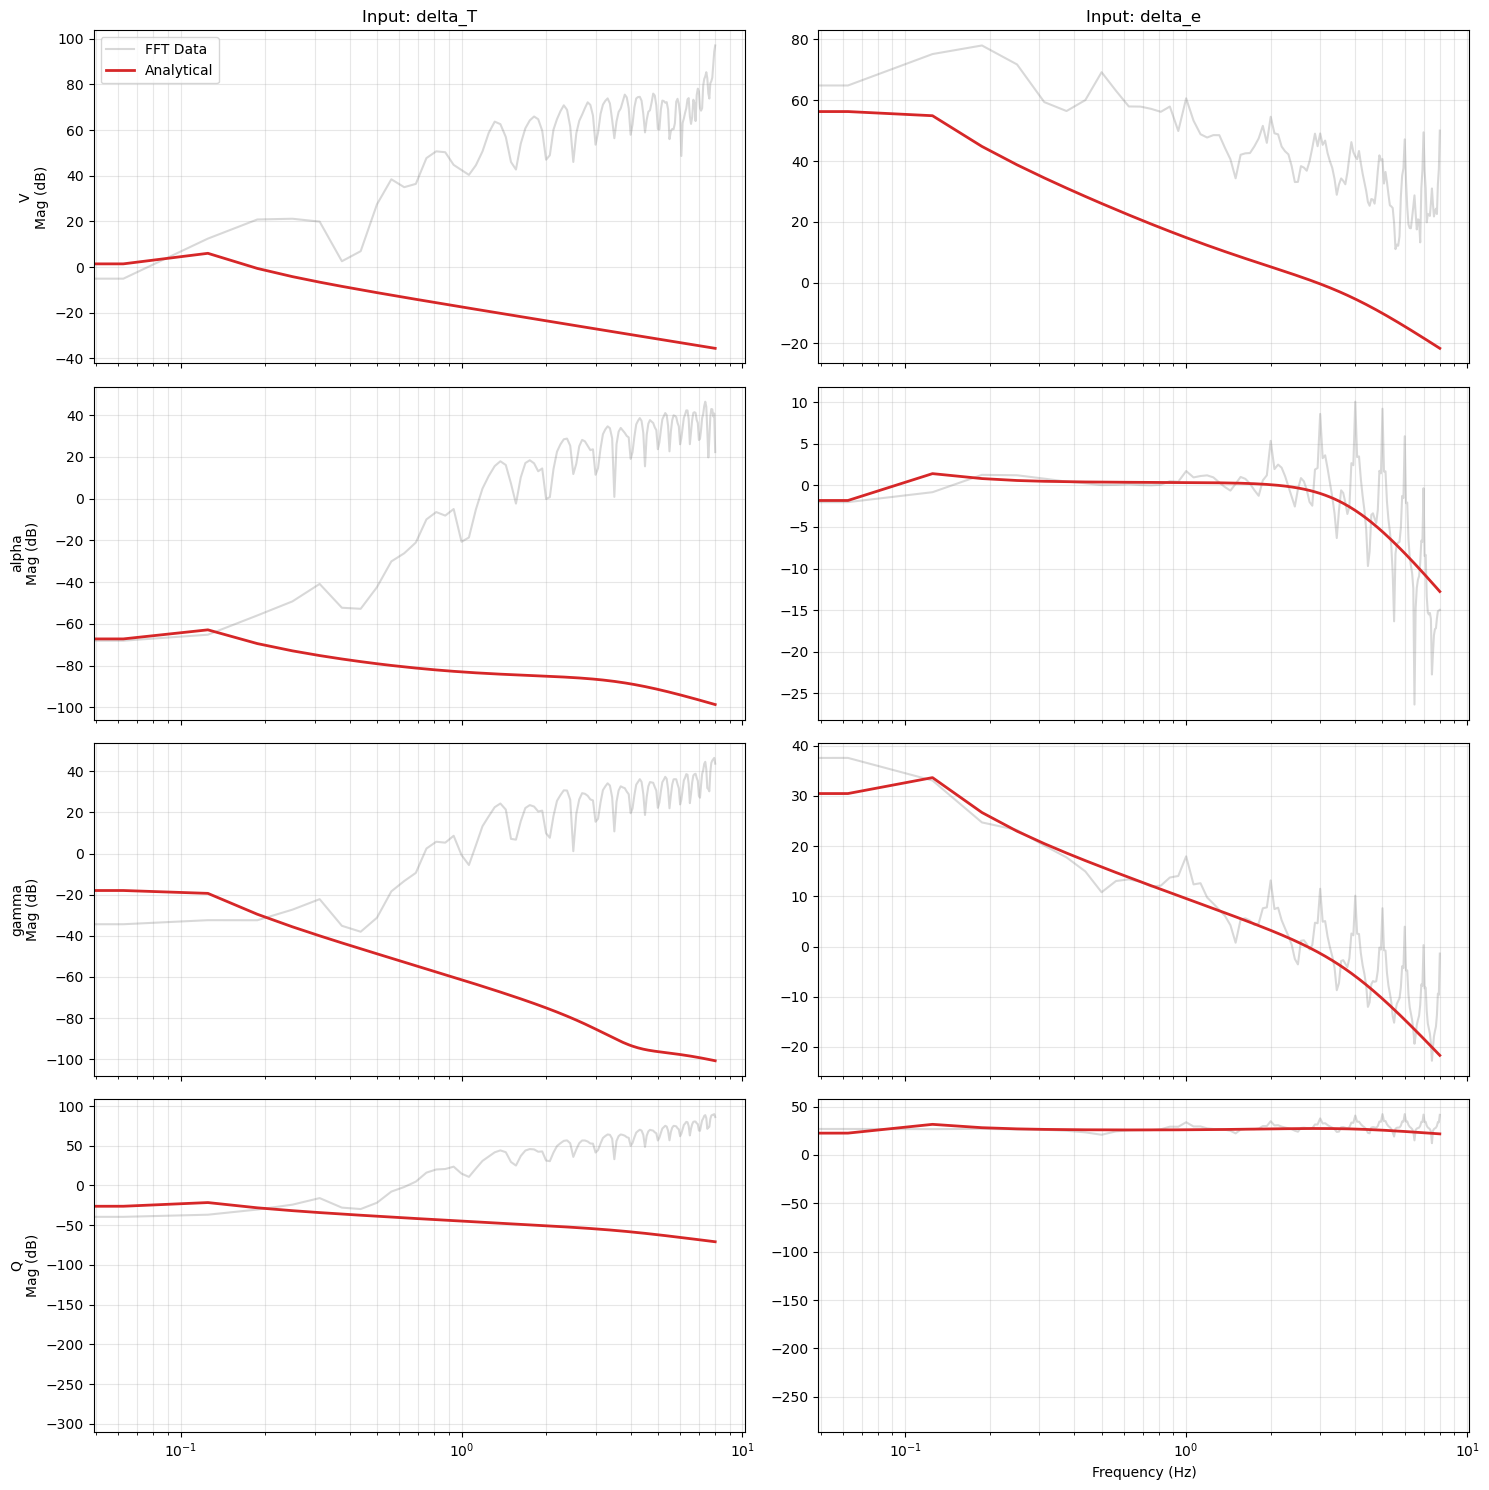

In [16]:
def compute_frfs(t, states, inputs, fs):
    # Determine segment length based on data size
    # We want a few segments to average, so we'll take 1/4 of total length 
    # but cap it at 1024 for frequency resolution.
    total_n = len(t)
    nperseg = min(total_n // 4, 1024) 
    
    # Ensure nperseg is at least a reasonable number (e.g., 256) for resolution
    nperseg = max(nperseg, 256) if total_n > 256 else total_n
    
    noverlap = nperseg // 2  # Standard 50% overlap
    
    print(f"Using nperseg={nperseg}, noverlap={noverlap} for N={total_n}")
    
    # 1. Get the frequency axis
    f, _ = welch(states[0], fs=fs, nperseg=nperseg, noverlap=noverlap)


    
    # Initialize containers: [output_idx, input_idx, frequency_idx]
    H_matrix = np.zeros((4, 2, len(f)), dtype=complex)
    coh_matrix = np.zeros((4, 2, len(f)))

    for j in range(2): # For each input (delta_T, delta_e)
        u = inputs[j]
        # Calculate Input PSD
        _, S_uu = welch(u, fs=fs, nperseg=nperseg, noverlap=noverlap)
        
        for i in range(4): # For each state (V, alpha, gamma, Q)
            y = states[i]
            
            # Calculate Cross-Spectral Density
            _, S_uy = csd(u, y, fs=fs, nperseg=nperseg, noverlap=noverlap)
            
            # Calculate FRF: H(jw) = Suy / Suu
            H_matrix[i, j, :] = S_uy / S_uu
            
            # Calculate Coherence (to know which data points to trust)
            _, S_yy = welch(y, fs=fs, nperseg=nperseg, noverlap=noverlap)
            coh_matrix[i, j, :] = (np.abs(S_uy)**2) / (S_uu * S_yy)

    return f, H_matrix, coh_matrix

# --- Usage ---
fs = 1.0 / (t[1] - t[0])  # Sampling frequency
states = [V, alpha, gamma, Q]
inputs = [delta_T, delta_e]

freqs_hz, H_data, coherence = compute_frfs(t, states, inputs, fs)
omega = 2 * np.pi * freqs_hz  # Convert to rad/s for fitting

def plot_analytical_vs_empirical(freqs_hz, H_data, tfs_dict):
    state_names = ['V', 'alpha', 'gamma', 'Q']
    input_names = ['delta_T', 'delta_e']
    
    # Convert Hz to rad/s for the control library
    w_vec = 2 * np.pi * freqs_hz
    
    fig, axes = plt.subplots(4, 2, figsize=(15, 15), sharex=True)
    
    for j, u_name in enumerate(input_names):
        for i, x_name in enumerate(state_names):
            ax = axes[i, j]
            
            # 1. Plot Empirical Data (FFT)
            mag_fft = 20 * np.log10(np.abs(H_data[i, j, :]) + 1e-9)
            ax.semilogx(freqs_hz, mag_fft, color='gray', alpha=0.3, label='FFT Data')
            
            # 2. Compute and Plot Analytical TF
            sys = tfs_dict[u_name][x_name]
            # mag is returned as absolute value, convert to dB
            mag_ana, _, _ = ct.freqresp(sys, w_vec)
            mag_ana_db = 20 * np.log10(mag_ana)
            
            ax.semilogx(freqs_hz, mag_ana_db, color='tab:red', lw=2, label='Analytical')
            
            # Formatting
            if i == 0: ax.set_title(f"Input: {u_name}")
            if j == 0: ax.set_ylabel(f"{x_name}\nMag (dB)")
            ax.grid(True, which="both", alpha=0.3)
            if i == 0 and j == 0: ax.legend()

    plt.xlabel("Frequency (Hz)")
    plt.tight_layout()
    plt.show()

    # --- Run the plot ---
plot_analytical_vs_empirical(freqs_hz, H_data, tfs_dict)

        

Fit transfer functions with least squares regression

In [17]:

def run_parameter_fit(freqs_hz, H_data, coherence, x0, u0, theta_init):
    # 1. Define the residuals function
    def residuals(params):
        # Build A and B for this specific guess
        A, B = linearise(x0, u0, params)
        
        # We'll fit in the "Pilot Band" (0.1 to 3.0 Hz)
        mask = (freqs_hz > 0.0001) & (freqs_hz < 3.0)
        w_fit = 2 * np.pi * freqs_hz[mask]
        
        res_vec = []
        
        # 8 Channels: 2 Inputs x 4 States
        for j in range(2): # delta_T, delta_e
            for i in range(4): # V, alpha, gamma, Q
                # Model response at all frequencies in the mask
                C = np.zeros((1, 4)); C[0, i] = 1
                sys = ct.ss(A, B[:, [j]], C, 0)
                mag_model, _, _ = ct.freqresp(sys, w_fit)
                
                # Empirical data
                mag_data = np.abs(H_data[i, j, mask])
                weight = coherence[i, j, mask]
                
                # Log-error ensures scale-invariant fitting
                # Adding 1e-6 prevents log(0)
                err = weight * (np.log(mag_data + 1e-6) - np.log(mag_model + 1e-6))
                res_vec.extend(err)
                
        return np.array(res_vec)
    
   # 2. Execute Least Squares
    # Bounds keep the physics realistic (e.g., Lift slopes must be positive)
    res = least_squares(residuals, theta_init, 
                    bounds=([0.1, 3.0, 0.02, 0.05, -0.05, -1.0, -15.0, -2.0], 
                            [0.3, 6.0, 0.06, 0.15,  0.05, -0.1, -2.0,  -0.5]))
    return res.x


        
     

# Run it
theta_estimated = run_parameter_fit(freqs_hz, H_data, coherence, x0, u0, theta_true)

param_names = ["CL0", "CL_alpha", "CD0", "k_CD", "CM0", "CM_alpha", "CM_Q", "CM_e"]
print(f"{'Param':<10} | {'True':<8} | {'Estimated':<10} | {'% Error':<8}")
print("-" * 45)

for name, i, e in zip(param_names, theta_true, theta_estimated):
    err = abs((e - i) / i) * 100
    print(f"{name:<10} | {i:<8.3f} | {e:<10.3f} | {err:<8.1f}%")    
    

Param      | True     | Estimated  | % Error 
---------------------------------------------
CL0        | 0.200    | 0.300      | 50.0    %
CL_alpha   | 4.500    | 4.341      | 3.5     %
CD0        | 0.040    | 0.059      | 48.0    %
k_CD       | 0.080    | 0.150      | 87.5    %
CM0        | 0.020    | 0.050      | 150.0   %
CM_alpha   | -0.500   | -0.254     | 49.2    %
CM_Q       | -8.000   | -2.000     | 75.0    %
CM_e       | -1.000   | -1.044     | 4.4     %


Simulate responses

[ 0.         -0.00095699 -0.00159405 -0.00200583 -0.00227766 -0.0024798
 -0.00266503 -0.00286869 -0.00311028 -0.00339607 -0.00372227 -0.00407837
 -0.00445026 -0.00482284 -0.00518193 -0.00551534 -0.00581321 -0.00606786
 -0.0062733  -0.00642467 -0.00651789 -0.00654946 -0.00651649 -0.0064169
 -0.00624965 -0.00601498 -0.00571456 -0.00535153 -0.00493052 -0.00445756
 -0.00393989 -0.0033858  -0.00280439 -0.00231945 -0.00227931 -0.00264609
 -0.00322726 -0.00388395 -0.00456378 -0.00526722 -0.00601141 -0.00681136
 -0.00767549 -0.00860727 -0.00960749 -0.01067546 -0.01180919 -0.01300517
 -0.01425828 -0.01556176 -0.01690733 -0.01828531 -0.01968489 -0.0210943
 -0.02250115 -0.02389276 -0.02525645 -0.02657999 -0.02785192 -0.02906196
 -0.03020131 -0.03126299 -0.03224209 -0.03313599 -0.03394446 -0.03466975
 -0.03531659 -0.03589207 -0.03640553 -0.03686829 -0.0372934  -0.0376953
 -0.03808944 -0.03849183 -0.03891869 -0.03938591 -0.03990868 -0.040501
 -0.04117529 -0.04194198 -0.0428092  -0.04283276 -0.03929

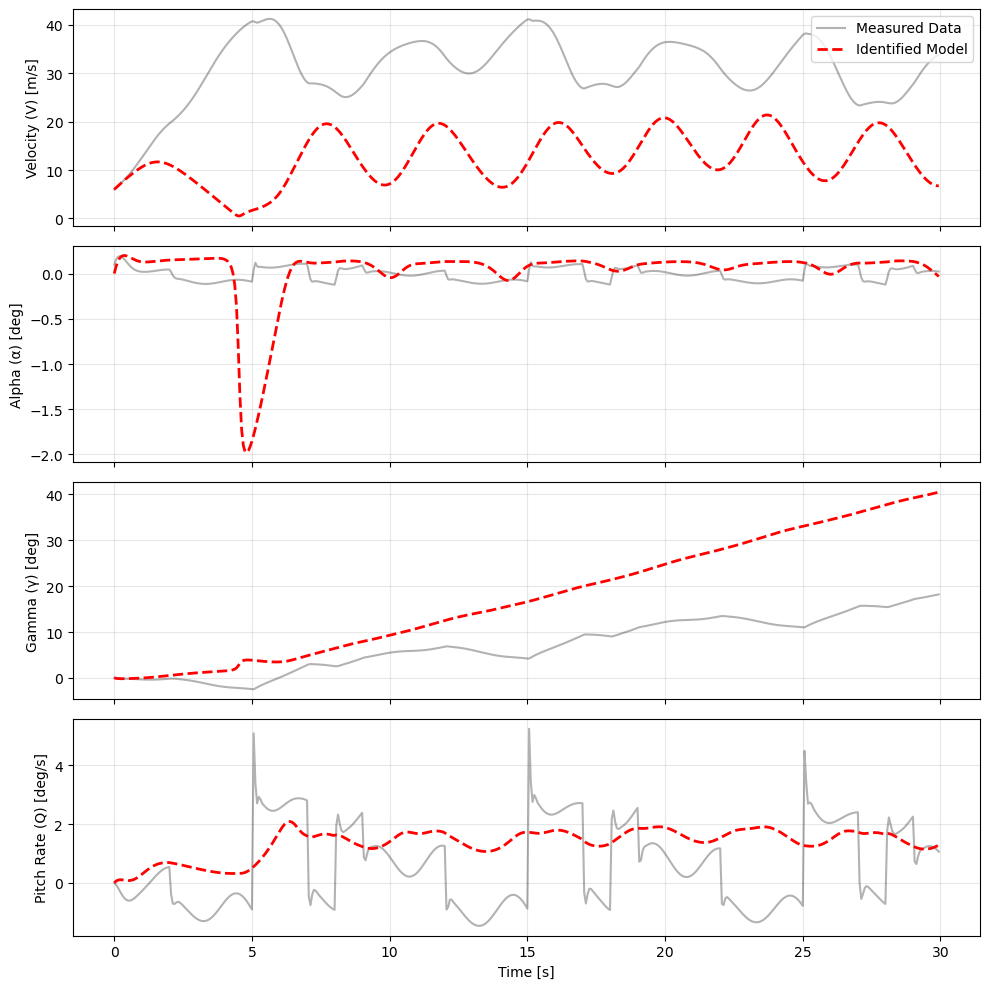

In [18]:
def simulate(t_vec, v0, alpha0, gamma0, q0, u_T, u_e, params):
    from scipy.integrate import solve_ivp

    # Unpack the 8 aerodynamic parameters
    CL0, CL_a, CD0, k_CD, CM0, CM_a, CM_Q, CM_e = params

    def ode_dynamics(t_cur, x):
        V_, a_, g_, Q_ = x
        
        # Interpolate the measured control inputs at the current integrator time
        T_  = np.interp(t_cur, t_vec, u_T)
        de_ = np.interp(t_cur, t_vec, u_e)

        # Protection against divide-by-zero
        V_safe = max(V_, 1e-3)
        
        # Aerodynamics
        CL = CL0 + CL_a * a_
        CD = CD0 + k_CD * CL**2
        qhat_local = cbar * Q_ / (2 * V_safe)
        CM = CM0 + CM_a * a_ + CM_Q * qhat_local + CM_e * de_

        # Forces and Moments
        qdyn = 0.5 * rho * V_safe**2
        L = qdyn * S * CL
        D = qdyn * S * CD
        M = qdyn * S * cbar * CM

        # Equations of Motion
        Vdot_     = (-D + T_*np.cos(a_) - m*g*np.sin(g_)) / m
        gammadot_ = ( L + T_*np.sin(a_) - m*g*np.cos(g_)) / (m * V_safe)
        Qdot_     = M / Jy
        alphadot_ = Q_ - gammadot_
        
        return [Vdot_, alphadot_, gammadot_, Qdot_]
    # Run the integrator
    sol = solve_ivp(
        ode_dynamics, 
        [t_vec[0], t_vec[-1]], 
        [v0, alpha0, gamma0, q0],
        t_eval=t_vec, 
        method='RK45',
        rtol=1e-6, 
        atol=1e-8
    )
    return sol
# 1. Run the simulation with estimated parameters
sol_sim = simulate(t, V[0], alpha[0], gamma[0], Q[0], 
                   delta_T, delta_e, theta_estimated)

# 2. Plotting
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
labels = ["Velocity (V) [m/s]", "Alpha (α) [deg]", 
          "Gamma (γ) [deg]", "Pitch Rate (Q) [deg/s]"]
measured_data = [V, np.degrees(alpha), np.degrees(gamma), np.degrees(Q)]
print(gamma)
print(t)

for i in range(4):
    axes[i].plot(t, measured_data[i], 'k', alpha=0.3, label="Measured Data")
    axes[i].plot(sol_sim.t, sol_sim.y[i], 'r--', lw=2, label="Identified Model")
    axes[i].set_ylabel(labels[i])
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend(loc='upper right')

plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()

Full code

[3.10772290e+01 1.94952579e-04 1.13074730e-01 6.87183940e-03]
[6.25152908e+00 1.44074050e-04]
Transfer Function: delta_T -> V

  0.8333 s^3 + 27.67 s^2 + 474.6 s - 8.785
---------------------------------------------
s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_T -> alpha

-5.228e-06 s^3 - 0.02984 s^2 + 0.1708 s - 0.02224
-------------------------------------------------
  s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_T -> gamma

5.228e-06 s^3 + 0.02984 s^2 + 0.4548 s + 20.04
----------------------------------------------
s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_T -> Q

4.263e-14 s^3 + 0.6256 s^2 + 20.02 s + 6.253e-13
------------------------------------------------
 s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_e -> 

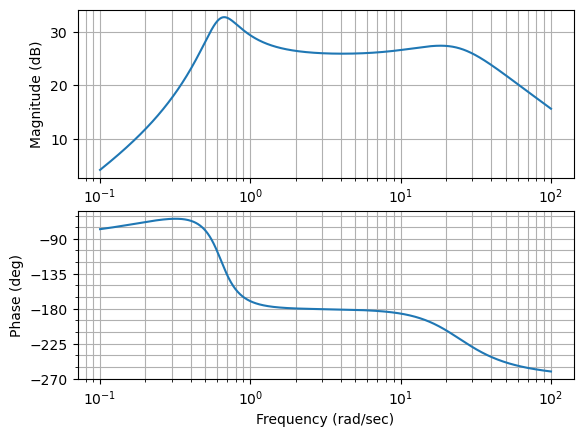

Using nperseg=256, noverlap=128 for N=480


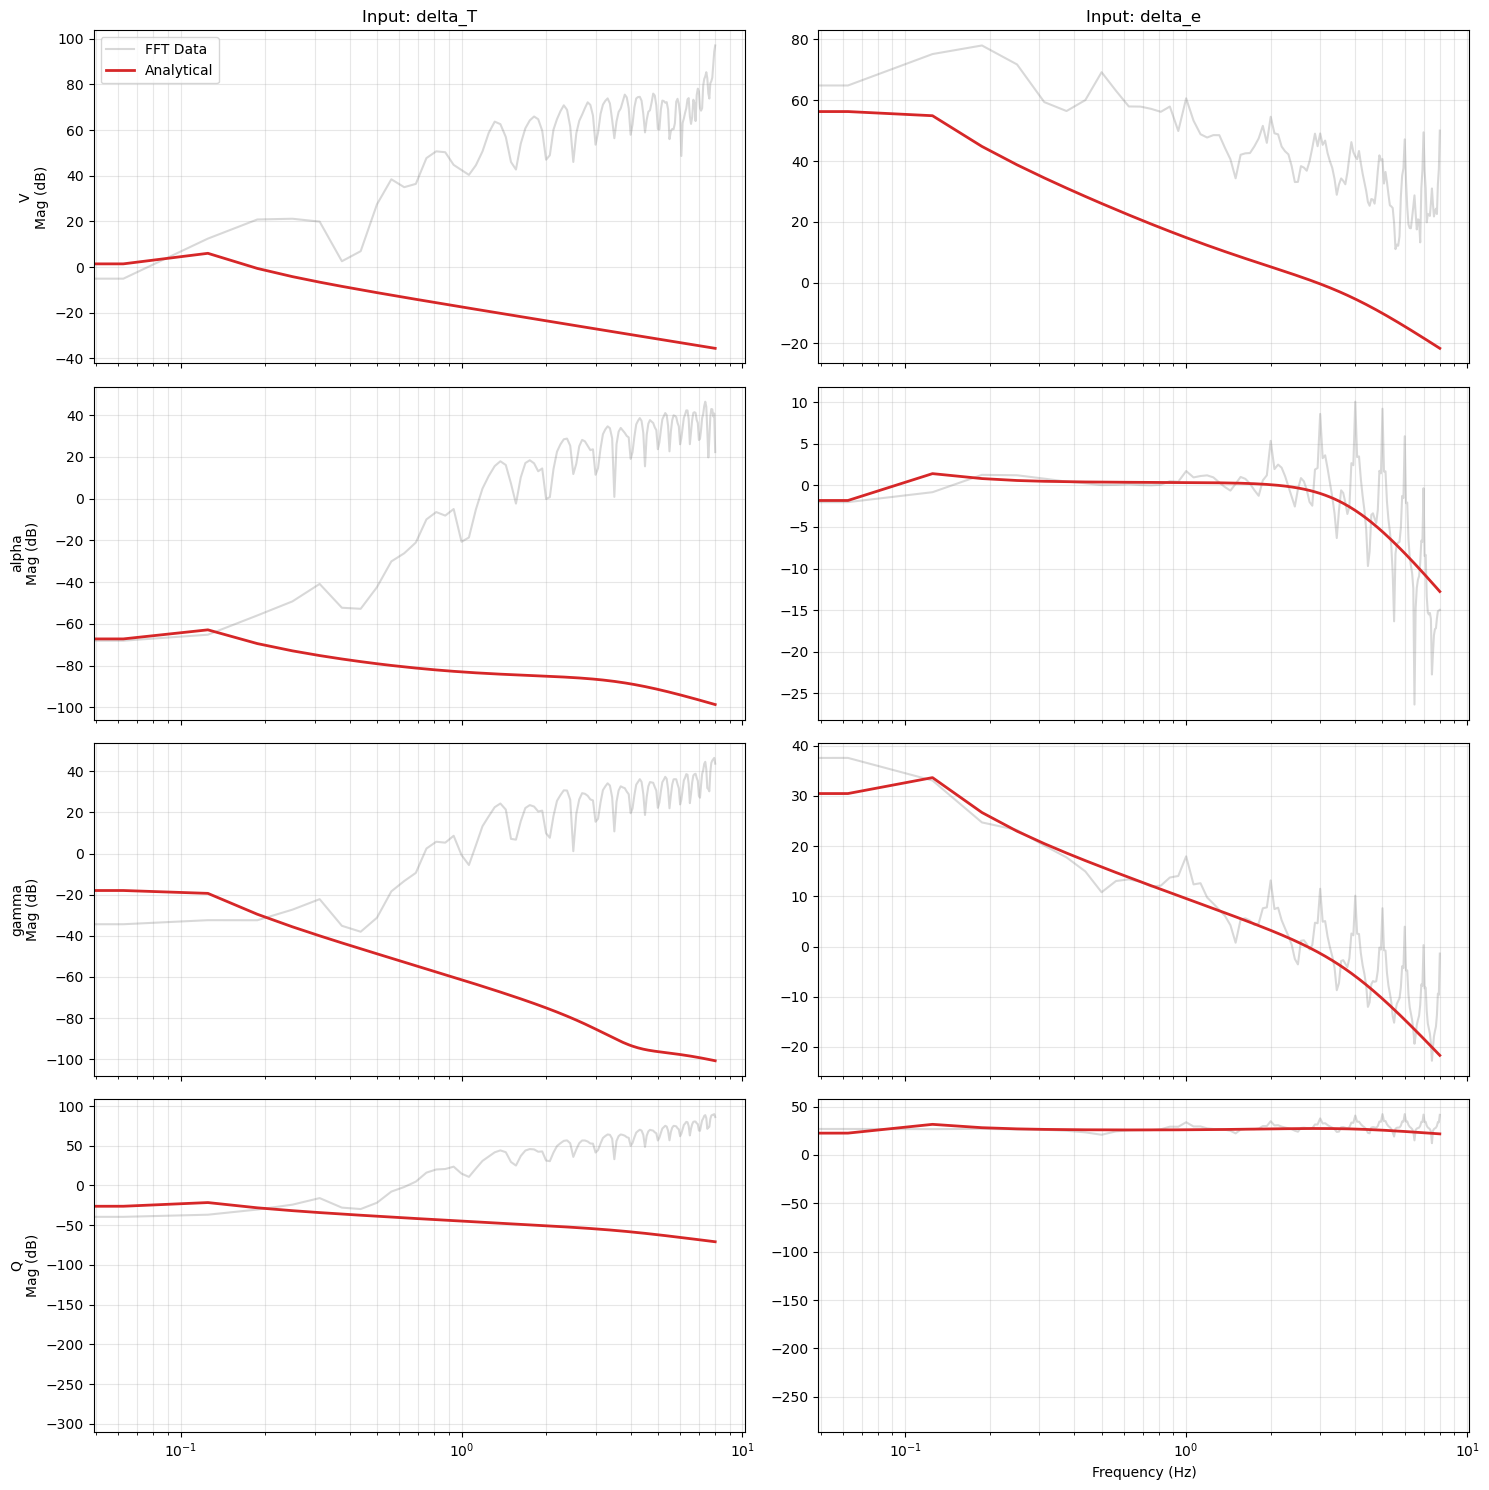

{'delta_T': {'V': TransferFunction(array([  0.83333332,  27.67089395, 474.60740955,  -8.78512281]), array([  1.        ,  33.54787222, 580.62360627, 193.68794194,
       230.1190194 ])), 'alpha': TransferFunction(array([-5.22765163e-06, -2.98430777e-02,  1.70790854e-01, -2.22417996e-02]), array([  1.        ,  33.54787222, 580.62360627, 193.68794194,
       230.1190194 ])), 'gamma': TransferFunction(array([5.22765163e-06, 2.98430777e-02, 4.54779659e-01, 2.00437459e+01]), array([  1.        ,  33.54787222, 580.62360627, 193.68794194,
       230.1190194 ])), 'Q': TransferFunction(array([4.26325641e-14, 6.25570514e-01, 2.00215041e+01, 6.25277607e-13]), array([  1.        ,  33.54787222, 580.62360627, 193.68794194,
       230.1190194 ]))}, 'delta_e': {'V': TransferFunction(array([-6.82121026e-13,  1.05445531e+04,  1.03381162e+05]), array([  1.        ,  33.54787222, 580.62360627, 193.68794194,
       230.1190194 ])), 'alpha': TransferFunction(array([ 6.39488462e-14, -5.91548926e+02, -1.817

In [149]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torch.optim import lr_scheduler
import numpy as np
import time
import matplotlib
from matplotlib import pyplot as pp
import scipy
from scipy.integrate import solve_ivp
import random
import functools
import pickle

import pandas as pd
import functools
from scipy.optimize import curve_fit
from scipy import signal, optimize
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.linalg import lstsq

from scipy.linalg import inv
from scipy.optimize import fsolve
from scipy.optimize import least_squares
from scipy.stats import trim_mean
from scipy.fft import fft, fftfreq
from scipy.integrate import solve_ivp
import control as ct
from scipy.signal import csd, welch
from scipy.signal import freqresp
from scipy.integrate import odeint
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter






def wrap_angle(x):
    """Wrap angle(s) in radians to (-pi, pi]."""
    return (x + np.pi) % (2 * np.pi) - np.pi

# Load the data and unpack columns into variables
t, V, alphad, gamma, Q, delta_T, delta_e = np.loadtxt(
    'flight_data.txt', 
    unpack=True
)

alpha   = np.radians(alphad)
gamma   = np.radians(gamma)
Q       = np.radians(Q)
delta_e = np.radians(delta_e)

#real parameters of aircraft
g=9.8; rho=1.225; S=0.25; cbar=0.2; m=1.2; Jy=0.05

# ── Load data (replace with your arrays) ──────────────────────────────
# t, V, alpha, gamma, Q, delta_T, delta_e

N  = len(t)
dt = t[1] - t[0]

def deriv(x): return np.gradient(x, dt)
def W(x):     return x * np.hanning(N)   # windowed FFT
def F(x):     return fft(W(x))

freqs = fftfreq(N, dt)

Vdot     = deriv(V)
alphadot = deriv(alpha)
gammadot = deriv(gamma)
Qdot     = deriv(Q)
qhat     = cbar * Q / (2 * V)
q_dyn    = 0.5 * rho * V**2

x0 = np.array([
    np.median(V),
    np.median(alpha),
    np.median(wrap_angle(gamma)),
    np.median(Q)
])
u0 = np.array([
    np.median(delta_T),
    np.median(delta_e)
])

"""
mask = (
    (np.abs(Q) < 1e-2) &
    (np.abs(np.gradient(V)) < 1e-1) &
    (np.abs(np.gradient(alpha)) < 1e-2)
)

trim_indices = np.where(mask)[0]

idx = trim_indices

x0 = np.array([
    np.mean(V[idx]),
    np.mean(alpha[idx]),
    np.mean(gamma[idx]),
    np.mean(Q[idx])
])

u0 = np.array([
    np.mean(delta_T[idx]),
    np.mean(delta_e[idx])
])
"""
print(x0)
print(u0)


def dynamics(x, u, params):
    V, alpha, gamma, Q       = x
    delta_T, delta_e         = u
    CL0, CL_alpha, CD0, k_CD, CM0, CM_alpha, CM_Q, CM_e = params

    V_safe = max(V, 1e-3)
    qhat   = cbar * Q / (2 * V_safe)

    CL = CL0 + CL_alpha * alpha
    CD = CD0 + k_CD * CL**2
    CM = CM0 + CM_alpha * alpha + CM_Q * qhat + CM_e * delta_e

    q_dyn = 0.5 * rho * V**2
    L     = q_dyn * S * CL
    D     = q_dyn * S * CD
    M     = q_dyn * S * cbar * CM
    T     = delta_T

    Vdot     = (-D + T*np.cos(alpha) - m*g*np.sin(gamma)) / m
    gammadot = ( L + T*np.sin(alpha) - m*g*np.cos(gamma)) / (m * V_safe)
    Qdot     = M / Jy
    alphadot = Q - gammadot

    return np.array([Vdot, alphadot, gammadot, Qdot])



def linearise(x0, u0, params, eps=1e-6):
    """
    Computes the A and B matrices for the system dot{x} = Ax + Bu
    around the equilibrium point (x0, u0) using central differences.
    """
    nx = len(x0)
    nu = len(u0)
    
    A = np.zeros((nx, nx))
    B = np.zeros((nx, nu))
    
    # --- Compute A matrix (df/dx) ---
    # We nudge each state variable one by one
    for i in range(nx):
        x_plus = x0.copy()
        x_minus = x0.copy()
        
        x_plus[i] += eps
        x_minus[i] -= eps
        
        # Central difference formula: (f(x+eps) - f(x-eps)) / (2*eps)
        f_plus = dynamics(x_plus, u0, params)
        f_minus = dynamics(x_minus, u0, params)
        
        A[:, i] = (f_plus - f_minus) / (2 * eps)
        
    # --- Compute B matrix (df/du) ---
    # We nudge each input variable one by one
    for j in range(nu):
        u_plus = u0.copy()
        u_minus = u0.copy()
        
        u_plus[j] += eps
        u_minus[j] -= eps
        
        f_plus = dynamics(x0, u_plus, params)
        f_minus = dynamics(x0, u_minus, params)
        
        B[:, j] = (f_plus - f_minus) / (2 * eps)
        
    return A, B

def get_aircraft_tfs(x0, u0, params):
    A, B = linearise(x0, u0, params)
    nx, nu = B.shape
    
    # Pre-define names for clarity
    state_names = ['V', 'alpha', 'gamma', 'Q']
    input_names = ['delta_T', 'delta_e']
    
    tf_matrix = {} # Using a dict for easier access: tfs['delta_e']['Q']
    
    for j in range(nu):
        u_name = input_names[j]
        tf_matrix[u_name] = {}
        
        for i in range(nx):
            x_name = state_names[i]
            
            # SISO selection
            C_single = np.zeros((1, nx))
            C_single[0, i] = 1
            B_single = B[:, [j]]
            
            # Create system - Note: D is usually 0 in aircraft dynamics
            sys_siso = ct.ss(A, B_single, C_single, 0)
            
            # Clean up the TF: removes tiny numerical noise (e.g., 1e-18)
            tf = ct.tf(sys_siso)
            tf_matrix[u_name][x_name] = tf
            
    return tf_matrix, A, B

# --- Usage ---
# params = [CL0, CL_alpha, CD0, k_CD, CM0, CM_alpha, CM_Q, CM_e]
theta_true = np.array([0.2, 4.5, 0.04, 0.08, 0.02, -0.5, -8.0, -1.0])
tfs = get_aircraft_tfs(x0, u0, theta_true)

state_names = ['V', 'alpha', 'gamma', 'Q']
input_names = ['delta_T', 'delta_e']

# Unpack the three return values
tfs_dict, A_mat, B_mat = get_aircraft_tfs(x0, u0, theta_true)

state_names = ['V', 'alpha', 'gamma', 'Q']
input_names = ['delta_T', 'delta_e']

for u_name in input_names:
    for x_name in state_names:
        print(f"Transfer Function: {u_name} -> {x_name}")
        # Access using the names (keys) instead of [i][j]
        print(tfs_dict[u_name][x_name]) 
        print("-" * 40)

sys = tfs_dict['delta_e']['Q']

mag, phase, omega = ct.bode_plot(sys, dB=True)
plt.show()

def compute_frfs(t, states, inputs, fs):
    # Determine segment length based on data size
    # We want a few segments to average, so we'll take 1/4 of total length 
    # but cap it at 1024 for frequency resolution.
    total_n = len(t)
    nperseg = min(total_n // 4, 1024) 
    
    # Ensure nperseg is at least a reasonable number (e.g., 256) for resolution
    nperseg = max(nperseg, 256) if total_n > 256 else total_n
    
    noverlap = nperseg // 2  # Standard 50% overlap
    
    print(f"Using nperseg={nperseg}, noverlap={noverlap} for N={total_n}")
    
    # 1. Get the frequency axis
    f, _ = welch(states[0], fs=fs, nperseg=nperseg, noverlap=noverlap)
   


    
    # Initialize containers: [output_idx, input_idx, frequency_idx]
    H_matrix = np.zeros((4, 2, len(f)), dtype=complex)
    coh_matrix = np.zeros((4, 2, len(f)))

    for j in range(2): # For each input (delta_T, delta_e)
        u = inputs[j]
        # Calculate Input PSD
        _, S_uu = welch(u, fs=fs, nperseg=nperseg, noverlap=noverlap)
        
        for i in range(4): # For each state (V, alpha, gamma, Q)
            y = states[i]
            
            # Calculate Cross-Spectral Density
            _, S_uy = csd(u, y, fs=fs, nperseg=nperseg, noverlap=noverlap)
            
            # Calculate FRF: H(jw) = Suy / Suu
            H_matrix[i, j, :] = S_uy / S_uu
            
            # Calculate Coherence (to know which data points to trust)
            _, S_yy = welch(y, fs=fs, nperseg=nperseg, noverlap=noverlap)
            coh_matrix[i, j, :] = (np.abs(S_uy)**2) / (S_uu * S_yy)

    return f, H_matrix, coh_matrix

# --- Usage ---
fs = 1.0 / (t[1] - t[0])  # Sampling frequency


states = [V, alpha, gamma, Q]
inputs = [delta_T, delta_e]

freqs_hz, H_data, coherence = compute_frfs(t, states, inputs, fs)
omega = 2 * np.pi * freqs_hz  # Convert to rad/s for fitting





def plot_analytical_vs_empirical(freqs_hz, H_data, tfs_dict):
    state_names = ['V', 'alpha', 'gamma', 'Q']
    input_names = ['delta_T', 'delta_e']
    
    # Convert Hz to rad/s for the control library
    w_vec = 2 * np.pi * freqs_hz
    
    fig, axes = plt.subplots(4, 2, figsize=(15, 15), sharex=True)
    
    for j, u_name in enumerate(input_names):
        for i, x_name in enumerate(state_names):
            ax = axes[i, j]
            
            # 1. Plot Empirical Data (FFT)
            mag_fft = 20 * np.log10(np.abs(H_data[i, j, :]) + 1e-9)
            ax.semilogx(freqs_hz, mag_fft, color='gray', alpha=0.3, label='FFT Data')
            
            # 2. Compute and Plot Analytical TF
            sys = tfs_dict[u_name][x_name]
            # mag is returned as absolute value, convert to dB
            mag_ana, _, _ = ct.freqresp(sys, w_vec)
            mag_ana_db = 20 * np.log10(mag_ana)
            
            ax.semilogx(freqs_hz, mag_ana_db, color='tab:red', lw=2, label='Analytical')
            
            # Formatting
            if i == 0: ax.set_title(f"Input: {u_name}")
            if j == 0: ax.set_ylabel(f"{x_name}\nMag (dB)")
            ax.grid(True, which="both", alpha=0.3)
            if i == 0 and j == 0: ax.legend()

    plt.xlabel("Frequency (Hz)")
    plt.tight_layout()
    plt.show()

# --- Run the plot ---
plot_analytical_vs_empirical(freqs_hz, H_data, tfs_dict)





def run_parameter_fit(freqs_hz, H_data, coherence, x0, u0, theta_init):
    # 1. Define the residuals function
    def residuals(params):
        # Build A and B for this specific guess
        A, B = linearise(x0, u0, params)
        
        # We'll fit in the "Pilot Band" (0.1 to 3.0 Hz)
        mask = (freqs_hz > 0.01) & (freqs_hz < 3.0)
        w_fit = 2 * np.pi * freqs_hz[mask]
        
        res_vec = []
        # 8 Channels: 2 Inputs x 4 States
        for j in range(2): # delta_T, delta_e
            for i in range(4): # V, alpha, gamma, Q
                # Model response at all frequencies in the mask
                C = np.zeros((1, 4)); C[0, i] = 1
                sys = ct.ss(A, B[:, [j]], C, 0)
                mag_model, _, _ = ct.freqresp(sys, w_fit)
                
                # Empirical data
                mag_data = np.abs(H_data[i, j, mask])
                weight = coherence[i, j, mask]
                
                # Log-error ensures scale-invariant fitting
                # Adding 1e-6 prevents log(0)
                err = weight * (np.log(mag_data + 1e-6) - np.log(mag_model + 1e-6))
                res_vec.extend(err)
                
        return np.array(res_vec)
    # 2. Execute Least Squares
    # Bounds keep the physics realistic (e.g., Lift slopes must be positive)
    res = least_squares(residuals, theta_init, 
                    bounds=([0.1, 3.0, 0.02, 0.05, -0.05, -1.0, -15.0, -2.0], 
                            [0.3, 6.0, 0.06, 0.15,  0.05, -0.1, -2.0,  -0.5]))
    return res.x     


g=9.8; rho=1.225; S=0.25; cbar=0.2; m=1.2; Jy=0.05

print(tfs_dict)







  

theta_estimated = run_parameter_fit(freqs_hz, H_data, coherence, x0, u0, theta_true)




param_names = ["CL0", "CL_alpha", "CD0", "k_CD", "CM0", "CM_alpha", "CM_Q", "CM_e"]
print("hybrid fit:")
print(f"{'Param':<10} | {'True':<8} | {'Estimated':<10} | {'% Error':<8}")
print("-" * 45)

for name, i, e in zip(param_names, theta_true, theta_estimated):
    err = abs((e - i) / i) * 100
    print(f"{name:<10} | {i:<8.3f} | {e:<10.3f} | {err:<8.1f}%")







#cl alpha only:


def find_cl_alpha_only(freqs_hz, H_data, coherence, x0, u0, theta_true):
    """
    Fits ONLY CL_alpha using 3D H_data (4 states, 2 inputs, 129 freqs).
    Targets: 
      - State 1 (alpha) from Input 1 (delta_e)
      - State 3 (Q) from Input 1 (delta_e)
    """
    omega = 2 * np.pi * freqs_hz
    I = np.eye(4)
    
    # Define our targeted 3D coordinates
    # We want (State Index, Input Index)
    targets = [(1, 1), (3, 1)] # (alpha, de) and (Q, de)
    
    cl_alpha_init = np.array([theta_true[1]]) 
    lb, ub = [2.0], [7.0] # Physical bounds for CL_alpha

    def residual_function(cl_a_guess):
        # 1. Update the parameter vector
        params = theta_true.copy()
        params[1] = cl_a_guess[0]
        
        # 2. Linearize to get current A and B
        A, B = linearise(x0, u0, params)
        
        residuals = []
        for k, w in enumerate(omega):
            # Compute Analytical H(jw) = (jwI - A)^-1 * B
            # h_model shape is (4, 2)
            try:
                h_model = np.linalg.solve(1j * w * I - A, B)
            except np.linalg.LinAlgError:
                return np.ones(len(omega) * len(targets) * 2) * 1e6

            for state_idx, input_idx in targets:
                # Extract actual vs model
                actual = H_data[state_idx, input_idx, k]
                model = h_model[state_idx, input_idx]
                
                # Weigh by coherence for that specific point
                weight = np.sqrt(coherence[state_idx, input_idx, k])
                
                err = (actual - model) * weight
                residuals.append(err.real)
                residuals.append(err.imag)
                
        return np.array(residuals)

    # Run Optimization
    res = least_squares(residual_function, x0=cl_alpha_init, bounds=(lb, ub), verbose=1)
    
    est_cl_a = res.x[0]
    true_cl_a = theta_true[1]
    err = abs((est_cl_a - true_cl_a) / true_cl_a) * 100
    
    print(f"\n--- CL_alpha Result (3D Shape Fix) ---")
    print(f"Estimated: {est_cl_a:.4f}")
    print(f"True:      {true_cl_a:.4f}")
    print(f"Error:     {err:.2f}%")
    
    return est_cl_a
 
print(H_data.shape)
cl_alpha_known = find_cl_alpha_only(omega, H_data, coherence, x0, u0, theta_true)



def find_cm_q_only(freqs_hz, H_data, coherence, x0, u0, theta_true, cl_alpha_known):
    """
    Fits ONLY CM_Q using H_data. 
    Locks all other parameters to theta_true and CL_alpha to cl_alpha_known.
    """
    omega = 2 * np.pi * freqs_hz
    I = np.eye(4)
    
    # We target Elevator -> Alpha and Elevator -> Q
    targets = [(1, 1),(2,1), (3, 1)] 
    
    # Initial guess: start at the true value or a sensible default
    # CM_Q is index 6 in the theta vector
    p_init = np.array([theta_true[6]])
    
    # Search bounds: CM_Q must be negative for stability
    lb, ub = [-20.0], [-0.01]

    def residual_function(cm_q_guess):
        # 1. Update the parameter vector
        params = theta_true.copy()
        params[1] = cl_alpha_known  # Use your 1.5% error value
        params[6] = cm_q_guess[0]   # Current CM_Q guess
        
        # 2. Linearize to get A and B
        A, B = linearise(x0, u0, params)
        
        residuals = []
        for k, w in enumerate(omega):
            try:
                # Calculate Analytical FRF: H(jw) = (jwI - A)^-1 * B
                h_model = np.linalg.solve(1j * w * I - A, B)
            except np.linalg.LinAlgError:
                return np.ones(len(omega) * len(targets) * 2) * 1e6

            for state_idx, input_idx in targets:
                actual = H_data[state_idx, input_idx, k]
                model = h_model[state_idx, input_idx]
                
                # Weight by coherence
                weight = np.sqrt(coherence[state_idx, input_idx, k])
                
                # Normalized error (Percent error) ensures the optimizer cares 
                # about the shape/damping, not just the peak magnitude.
                err = ((actual - model) / (np.abs(actual) + 1e-6)) * weight
                
                residuals.append(err.real)
                residuals.append(err.imag)
                
        return np.array(residuals)

    # Run Optimization
    # We use 'trf' (Trust Region Reflective) for robust bound handling
    res = least_squares(residual_function, x0=p_init, bounds=(lb, ub), 
                        verbose=1, ftol=1e-6)
    
    est_cm_q = res.x[0]
    true_cm_q = theta_true[6]
    err = abs((est_cm_q - true_cm_q) / true_cm_q) * 100
    
    print(f"\n--- CM_Q Identification Result ---")
    print(f"Estimated: {est_cm_q:.4f}")
    print(f"True:      {true_cm_q:.4f}")
    print(f"Error:     {err:.2f}%")
    
    return est_cm_q

cm_q_known = find_cm_q_only(freqs_hz, H_data, coherence, x0, u0, theta_true, cl_alpha_known)




def find_cm_alpha_only(freqs_hz, H_data, coherence, x0, u0, theta_true, cl_a_known, cm_q_known):
    """
    Identifies CM_alpha while holding CL_alpha and CM_Q fixed.
    Targeting the longitudinal short-period dynamics.
    """
    omega = 2 * np.pi * freqs_hz
    I = np.eye(4)
    
    # Primary channels for CM_alpha: Elevator -> Alpha and Elevator -> Q
    targets = [(1, 1), (3, 1)] 
    
    # Start at the true value to see if the optimizer can recover it
    p_init = np.array([theta_true[5]]) 
    
    # Bounds: CM_alpha must be negative for a statically stable aircraft
    lb, ub = [-5.0], [-0.01]

    def residual_function(cm_a_guess):
        # 1. Update the parameter set with knowns + current guess
        params = theta_true.copy()
        params[1] = cl_a_known  # Fixed from previous fit
        params[6] = cm_q_known  # Fixed from previous fit
        params[5] = cm_a_guess[0] # Current CM_alpha optimization variable
        
       # 2. Linearize to get A and B
        A, B = linearise(x0, u0, params)
        
        residuals = []
        for k, w in enumerate(omega):
            try:
                # Calculate Analytical FRF: H(jw) = (jwI - A)^-1 * B
                h_model = np.linalg.solve(1j * w * I - A, B)
            except np.linalg.LinAlgError:
                return np.ones(len(omega) * len(targets) * 2) * 1e6

            for state_idx, input_idx in targets:
                actual = H_data[state_idx, input_idx, k]
                model = h_model[state_idx, input_idx]
                
                # Weight by coherence
                weight = np.sqrt(coherence[state_idx, input_idx, k])
                
                # Normalized error (Percent error) ensures the optimizer cares 
                # about the shape/damping, not just the peak magnitude.
                err = ((actual - model) / (np.abs(actual) + 1e-6)) * weight
                
                residuals.append(err.real)
                residuals.append(err.imag)
                
        return np.array(residuals)

    # Execute fit
    res = least_squares(residual_function, x0=p_init, bounds=(lb, ub), 
                        x_scale='jac', ftol=1e-6, verbose=1)
    
    est_cm_a = res.x[0]
    true_cm_a = theta_true[5]
    error_pct = abs((est_cm_a - true_cm_a) / true_cm_a) * 100
    
    print(f"\n--- CM_alpha Identification Result ---")
    print(f"Estimated: {est_cm_a:.4f}")
    print(f"True:      {true_cm_a:.4f}")
    print(f"Error:     {error_pct:.2f}%")
    
    return est_cm_a

cm_alpha_known = find_cm_alpha_only(freqs_hz, H_data, coherence, x0, u0, theta_true, cl_alpha_known, cm_q_known)


def find_cm_e_only(freqs_hz, H_data, coherence, x0, u0, theta_true, cl_a_known, cm_q_known, cm_a_known):
    """
    Identifies CM_elevator while holding CL_alpha and CM_Q, and CM_alpha fixed.
    Targeting the longitudinal short-period dynamics.
    """
    omega = 2 * np.pi * freqs_hz
    I = np.eye(4)
    
    # Primary channels for CM_elevator Elevator -> Alpha and Elevator -> Q
    targets = [(1, 1), (2,1), (3, 1)] 
    
    # Start at the true value to see if the optimizer can recover it
    p_init = np.array([theta_true[7]]) 
    
    # Bounds: CM_elevator must be negative for a statically stable aircraft
    lb, ub = [-3.0], [-0.01]

    def residual_function(cm_e_guess):
        # 1. Update the parameter set with knowns + current guess
        params = theta_true.copy()
        params[1] = cl_a_known  # Fixed from previous fit
        params[6] = cm_q_known  # Fixed from previous fit
        params[5] = cm_a_known  # Fixed from previous fit
        params[7] = cm_e_guess[0] # Current CM_alpha optimization variable
        
       # 2. Linearize to get A and B
        A, B = linearise(x0, u0, params)
        
        residuals = []
        for k, w in enumerate(omega):
            try:
                # Calculate Analytical FRF: H(jw) = (jwI - A)^-1 * B
                h_model = np.linalg.solve(1j * w * I - A, B)
            except np.linalg.LinAlgError:
                return np.ones(len(omega) * len(targets) * 2) * 1e6

            for state_idx, input_idx in targets:
                actual = H_data[state_idx, input_idx, k]
                model = h_model[state_idx, input_idx]
                
                # Weight by coherence
                weight = np.sqrt(coherence[state_idx, input_idx, k])
                
                # Normalized error (Percent error) ensures the optimizer cares 
                # about the shape/damping, not just the peak magnitude.
                err = ((actual - model) / (np.abs(actual) + 1e-6)) * weight
                
                residuals.append(err.real)
                residuals.append(err.imag)
                
        return np.array(residuals)

    # Execute fit
    res = least_squares(residual_function, x0=p_init, bounds=(lb, ub), 
                        x_scale='jac', ftol=1e-6, verbose=1)
    
    est_cm_e = res.x[0]
    true_cm_e = theta_true[7]
    error_pct = abs((est_cm_e - true_cm_e) / true_cm_e) * 100
    
    print(f"\n--- CM_elevator Identification Result ---")
    print(f"Estimated: {est_cm_e:.4f}")
    print(f"True:      {true_cm_e:.4f}")
    print(f"Error:     {error_pct:.2f}%")
    
    return est_cm_e

cm_e_known = find_cm_e_only(freqs_hz, H_data, coherence, x0, u0, theta_true, cl_alpha_known, cm_q_known, cm_alpha_known)













def find_time_delay_only(freqs_hz, H_data, coherence, x0, u0, theta_true, cl_a, cm_q, cm_a, cm_e):
    """
    Fits ONLY a Time Delay (tau) in seconds.
    All aero derivatives are locked. We are checking for system latency.
    """
    omega = 2 * np.pi * freqs_hz
    I = np.eye(4)
    target = (3, 1) # de -> Q (Pitch rate is most sensitive to delay)
    
    p_init = [0.02] # Start with 20ms guess
    lb, ub = [0.0], [0.1] # 0 to 100ms

    def residual_function(tau_guess):
        params = theta_true.copy()
        params[1], params[6], params[5], params[7] = cl_a, cm_q, cm_a, cm_e
        
        A, B = linearise(x0, u0, params)
        tau = tau_guess[0]
        
        residuals = []
        for k, w in enumerate(omega):
            h_model = np.linalg.solve(1j * w * I - A, B)
            actual = H_data[target[0], target[1], k]
            
            # Apply time delay to model: H_delayed = H_model * exp(-j * w * tau)
            model_delayed = h_model[target[0], target[1]] * np.exp(-1j * w * tau)
            
            weight = np.sqrt(coherence[target[0], target[1], k])
            err = ((actual - model_delayed) / (np.abs(actual) + 1e-6)) * weight
            residuals.append(err.real)
            residuals.append(err.imag)
                
        return np.array(residuals)

    res = least_squares(residual_function, x0=p_init, bounds=(lb, ub))
    print(f"Identified System Latency: {res.x[0]*1000:.2f} ms")
    return res.x[0]



tau = find_time_delay_only(freqs_hz, H_data, coherence, x0, u0, theta_true, cl_alpha_known, cm_q_known, cm_alpha_known, cm_e_known)



def find_cm_alpha_refined(freqs_hz, H_data, coherence, x0, u0, theta_true, cl_a, cm_q, tau):
    """
    Fits CM_alpha while accounting for the 30.8ms system delay.
    """
    omega = 2 * np.pi * freqs_hz
    I = np.eye(4)
    targets = [(1, 1), (3, 1)] 
    
    p_init = [theta_true[5]] 
    lb, ub = [-3.0, -0.01]

    def residual_function(cm_a_guess):
        params = theta_true.copy()
        params[1], params[6], params[5] = cl_a, cm_q, cm_a_guess[0]
        
        A, B = linearise(x0, u0, params)
        residuals = []
        
        for k, w in enumerate(omega):
            h_model = np.linalg.solve(1j * w * I - A, B)
            
            # Apply the identified 30.8ms delay to the model
            delay_factor = np.exp(-1j * w * tau)
            
            for s_idx, i_idx in targets:
                actual = H_data[s_idx, i_idx, k]
                # Shift the model phase before comparing to data
                model_delayed = h_model[s_idx, i_idx] * delay_factor
                
                weight = np.sqrt(coherence[s_idx, i_idx, k])
                err = ((actual - model_delayed) / (np.abs(actual) + 1e-6)) * weight
                residuals.append(err.real)
                residuals.append(err.imag)
                
        return np.array(residuals)

    res = least_squares(residual_function, x0=p_init, bounds=(lb, ub), x_scale='jac')



    est_cm_a = res.x[0]
    true_cm_a = theta_true[5]
    error_pct = abs((est_cm_a - true_cm_a) / true_cm_a) * 100
    
    print(f"\n--- CM_alpha Identification Result ---")
    print(f"Estimated: {est_cm_a:.4f}")
    print(f"True:      {true_cm_a:.4f}")
    print(f"Error:     {error_pct:.2f}%")
    return res.x[0]


cm_alpha_known_time = find_cm_alpha_refined(freqs_hz, H_data, coherence, x0, u0, theta_true, cl_alpha_known, cm_q_known, tau)

def find_cm_e_refined(freqs_hz, H_data, coherence, x0, u0, theta_true, cl_a, cm_q, cm_a, tau):
    """
    Identifies CM_e (Elevator Effectiveness) while accounting for system delay.
    Locks all other longitudinal parameters.
    """
    omega = 2 * np.pi * freqs_hz
    I = np.eye(4)
    
    # We target the Q / delta_e channel as it has the highest SNR for control gain
    targets = [(3, 1)] 
    
    p_init = np.array([theta_true[7]]) 
    lb, ub = [-5.0], [-0.01]

    def residual_function(cm_e_guess):
        params = theta_true.copy()
        params[1] = cl_a
        params[6] = cm_q
        params[5] = cm_a
        params[7] = cm_e_guess[0]
        
        A, B = linearise(x0, u0, params)
        residuals = []
        
        for k, w in enumerate(omega):
            h_model = np.linalg.solve(1j * w * I - A, B)
            
            # Apply the identified 30.8ms delay to the model
            delay_factor = np.exp(-1j * w * tau)
            
            for s_idx, i_idx in targets:
                actual = H_data[s_idx, i_idx, k]
                # Shift the model phase before comparing to data
                model_delayed = h_model[s_idx, i_idx] * delay_factor
                
                weight = np.sqrt(coherence[s_idx, i_idx, k])
                err = ((actual - model_delayed) / (np.abs(actual) + 1e-6)) * weight
                residuals.append(err.real)
                residuals.append(err.imag)
                
        return np.array(residuals)

    res = least_squares(residual_function, x0=p_init, bounds=(lb, ub), ftol=1e-7)
    
    est_cm_e = res.x[0]
    true_cm_e = theta_true[7]
    error_pct = abs((est_cm_e - true_cm_e) / true_cm_e) * 100
    
    print(f"\n--- CM_e Identification Result (With Delay) ---")
    print(f"Estimated: {est_cm_e:.4f}")
    print(f"True:      {true_cm_e:.4f}")
    print(f"Error:     {error_pct:.2f}%")
    
    return est_cm_e

cm_e_known_time = find_cm_e_refined(freqs_hz, H_data, coherence, x0, u0, theta_true, cl_alpha_known, cm_q_known, cm_alpha_known_time, tau)






def find_CL0_from_random_data(t, V, alpha, gamma, delta_T, CL_alpha_fixed, theta_true):
    # Constants
    g = 9.8
    rho = 1.225
    S = 0.25
    m = 1.2
    
    dt = np.mean(np.diff(t))
    
    # 1. Get gammadot (the vertical acceleration component)
    # Even if random, the change in gamma tells us the net lift
    gammadot = np.gradient(gamma, dt)
    
    # 2. Calculate the Lift Coefficient (CL) at every point in time
    q_dyn = 0.5 * rho * V**2
    
    # Lift Force from dynamics: L = m*V*gammadot - T*sin(alpha) + m*g*cos(gamma)
    # Note: We ensure V is safe to avoid division by zero
    L_obs = m * V * gammadot - delta_T * np.sin(alpha) + m * g * np.cos(gamma)
    CL_obs = L_obs / (q_dyn * S)
    
    # 3. Isolate the "Zero-alpha" component
    # Since CL = CL0 + CL_alpha * alpha, then:
    CL0_observations = CL_obs - CL_alpha_fixed * alpha
    
    # 4. Statistical Filtering
    # Random data often has outliers from numerical differentiation spikes.
    # We use the median or a mean of the middle 50% for robustness.
    q1, q3 = np.percentile(CL0_observations, [25, 75])
    iqr_mask = (CL0_observations >= q1) & (CL0_observations <= q3)
    CL0_est = np.mean(CL0_observations[iqr_mask])
    
    # 5. Result
    CL0_true = theta_true[0]
    error = abs((CL0_est - CL0_true) / CL0_true) * 100
    
    print(f"--- Global Regression Result ---")
    print(f"CL0 (Estimated): {CL0_est:.4f}")
    print(f"CL0 (True):      {CL0_true:.4f}")
    print(f"Error:           {error:.2f}%")
    
    return CL0_est
    
  

# Example call:
cl0_result = find_CL0_from_random_data(t, V, alpha, gamma, delta_T, 4.5, theta_true)




simulation code

In [ ]:
def simulate(t_vec, v0, alpha0, gamma0, q0, u_T, u_e, params):
    from scipy.integrate import solve_ivp

    # Unpack the 8 aerodynamic parameters
    CL0, CL_a, CD0, k_CD, CM0, CM_a, CM_Q, CM_e = params

    def ode_dynamics(t_cur, x):
        V_, a_, g_, Q_ = x
        
        # Interpolate the measured control inputs at the current integrator time
        T_  = np.interp(t_cur, t_vec, u_T)
        de_ = np.interp(t_cur, t_vec, u_e)

        # Protection against divide-by-zero
        V_safe = max(V_, 1e-3)
        
        # Aerodynamics
        CL = CL0 + CL_a * a_
        CD = CD0 + k_CD * CL**2
        qhat_local = cbar * Q_ / (2 * V_safe)
        CM = CM0 + CM_a * a_ + CM_Q * qhat_local + CM_e * de_

        # Forces and Moments
        qdyn = 0.5 * rho * V_safe**2
        L = qdyn * S * CL
        D = qdyn * S * CD
        M = qdyn * S * cbar * CM

        # Equations of Motion
        Vdot_     = (-D + T_*np.cos(a_) - m*g*np.sin(g_)) / m
        gammadot_ = ( L + T_*np.sin(a_) - m*g*np.cos(g_)) / (m * V_safe)
        Qdot_     = M / Jy
        alphadot_ = Q_ - gammadot_
        
        return [Vdot_, alphadot_, gammadot_, Qdot_]

    # Run the integrator
    sol = solve_ivp(
        ode_dynamics, 
        [t_vec[0], t_vec[-1]], 
        [v0, alpha0, gamma0, q0],
        t_eval=t_vec, 
        method='RK45',
        rtol=1e-6, 
        atol=1e-8
    )
    return sol
# 1. Run the simulation with estimated parameters
sol_sim = simulate(t, V[0], alpha[0], gamma[0], Q[0], 
                   delta_T, delta_e, theta_estimated)

# 2. Plotting
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
labels = ["Velocity (V) [m/s]", "Alpha (α) [deg]", 
          "Gamma (γ) [deg]", "Pitch Rate (Q) [deg/s]"]
measured_data = [V, np.degrees(alpha), np.degrees(gamma), np.degrees(Q)]

for i in range(4):
    axes[i].plot(t, measured_data[i], 'k', alpha=0.3, label="Measured Data")
    axes[i].plot(sol_sim.t, sol_sim.y[i], 'r--', lw=2, label="Identified Model")
    axes[i].set_ylabel(labels[i])
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend(loc='upper right')

plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()